In [1]:
import torch
import torch.nn as nn

models = {
    "Day 5 — XOR Solver (NumPy)": "2 inputs → 3 hidden → 1 output (Sigmoid)",
    "Day 6 — Iris Classifier":    "4 inputs → 8 hidden → 3 outputs (CrossEntropy)",
    "Day 7 — MNIST Classifier":   "784 → 128 → 64 → 10 (ReLU + Dropout)",
    "Day 12 — CNN (MNIST)":       "Conv32 → Conv64 → FC128 → 10",
    "Day 13 — CNN (CIFAR-10)":    "3×ConvBlocks(BN+Dropout) → FC512 → 10"
}

print("=" * 60)
print("PHASE 1 — PROJECTS BUILT")
print("=" * 60)
for name, arch in models.items():
    print(f"\n{name}")
    print(f"  Architecture: {arch}")

PHASE 1 — PROJECTS BUILT

Day 5 — XOR Solver (NumPy)
  Architecture: 2 inputs → 3 hidden → 1 output (Sigmoid)

Day 6 — Iris Classifier
  Architecture: 4 inputs → 8 hidden → 3 outputs (CrossEntropy)

Day 7 — MNIST Classifier
  Architecture: 784 → 128 → 64 → 10 (ReLU + Dropout)

Day 12 — CNN (MNIST)
  Architecture: Conv32 → Conv64 → FC128 → 10

Day 13 — CNN (CIFAR-10)
  Architecture: 3×ConvBlocks(BN+Dropout) → FC512 → 10


In [3]:
concepts = [
    ("Forward Pass",         "Can implement from scratch in NumPy"),
    ("Backpropagation",      "Derived chain rule manually on paper"),
    ("Gradient Descent",     "Implemented with loss landscape visualization"),
    ("Adam Optimizer",       "Read paper + implemented from scratch"),
    ("Autograd",             "Understand computational graph + zero_grad"),
    ("Overfitting/Underfit", "Visualized with toy data, applied Dropout/L2"),
    ("Batch Normalization",  "Implemented in CNN architecture"),
    ("Convolutions",         "Implemented manual 2D conv, understood weight sharing"),
    ("Data Augmentation",    "Applied on CIFAR-10 training pipeline"),
    ("Train/Val/Test Split", "Proper evaluation pipeline with early stopping"),
]

print("\n" + "=" * 60)
print("CONCEPTS MASTERED IN PHASE 1")
print("=" * 60)
for concept, evidence in concepts:
    print(f"\n --> {concept}")
    print(f"   → {evidence}")


CONCEPTS MASTERED IN PHASE 1

 --> Forward Pass
   → Can implement from scratch in NumPy

 --> Backpropagation
   → Derived chain rule manually on paper

 --> Gradient Descent
   → Implemented with loss landscape visualization

 --> Adam Optimizer
   → Read paper + implemented from scratch

 --> Autograd
   → Understand computational graph + zero_grad

 --> Overfitting/Underfit
   → Visualized with toy data, applied Dropout/L2

 --> Batch Normalization
   → Implemented in CNN architecture

 --> Convolutions
   → Implemented manual 2D conv, understood weight sharing

 --> Data Augmentation
   → Applied on CIFAR-10 training pipeline

 --> Train/Val/Test Split
   → Proper evaluation pipeline with early stopping


XOR final predictions: [0.02  0.96  0.959 0.053]
MNIST values loaded 
CIFAR-10 values loaded 


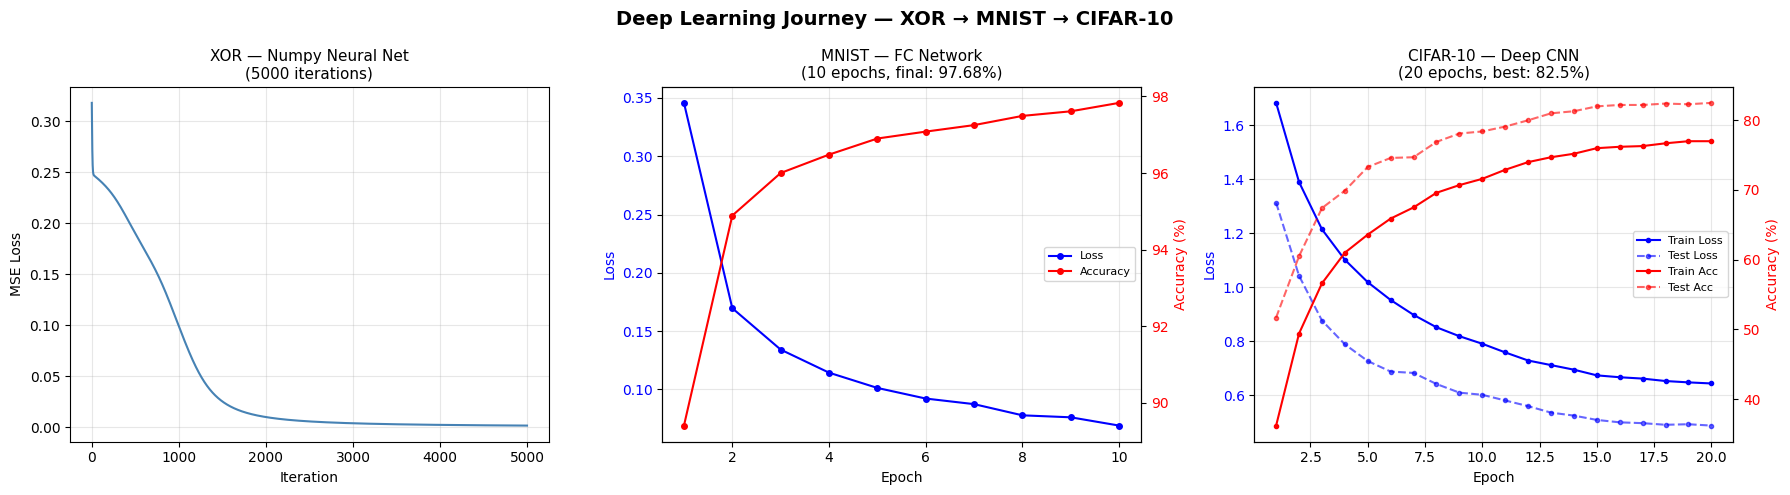

Saved → projects/journey_overview.png 


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ── 1. XOR Loss Curve ─────────────────────────────────────────
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x): s = sigmoid(x); return s*(1-s)

np.random.seed(42)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])
W1 = np.random.randn(2,3); b1 = np.zeros((1,3))
W2 = np.random.randn(3,1); b2 = np.zeros((1,1))
lr = 0.5; xor_losses = []

for _ in range(5000):
    Z1=X@W1+b1; A1=sigmoid(Z1); Z2=A1@W2+b2; A2=sigmoid(Z2)
    loss = np.mean((A2-y)**2); xor_losses.append(loss)
    dA2=2*(A2-y)/4; dZ2=dA2*sigmoid_deriv(Z2)
    W2-=lr*(A1.T@dZ2); b2-=lr*np.sum(dZ2,axis=0,keepdims=True)
    dA1=dZ2@W2.T; dZ1=dA1*sigmoid_deriv(Z1)
    W1-=lr*(X.T@dZ1); b1-=lr*np.sum(dZ1,axis=0,keepdims=True)

print(f"XOR final predictions: {np.round(A2.flatten(), 3)}")

# ── 2. MNIST real values (Day 7) ──────────────────────────────
mnist_losses = [0.3458, 0.1696, 0.1341, 0.1143, 0.1012,
                0.0921, 0.0873, 0.0777, 0.0760, 0.0689]
mnist_accs   = [89.41, 94.89, 96.00, 96.48, 96.90,
                97.08, 97.25, 97.49, 97.61, 97.83]
print("MNIST values loaded ")

# ── 3. CIFAR-10 real values (Day 13) ──────────────────────────
cifar_train_loss = [1.682, 1.389, 1.214, 1.101, 1.018,
                    0.952, 0.897, 0.851, 0.818, 0.790,
                    0.758, 0.728, 0.711, 0.694, 0.673,
                    0.666, 0.661, 0.652, 0.647, 0.643]

cifar_test_loss  = [1.312, 1.042, 0.876, 0.788, 0.726,
                    0.687, 0.682, 0.641, 0.609, 0.601,
                    0.580, 0.559, 0.535, 0.524, 0.508,
                    0.499, 0.496, 0.490, 0.492, 0.487]

cifar_train_acc  = [36.2, 49.4, 56.6, 61.0, 63.6,
                    65.9, 67.5, 69.6, 70.7, 71.6,
                    72.9, 74.0, 74.7, 75.2, 76.0,
                    76.2, 76.3, 76.7, 77.0, 77.0]

cifar_test_acc   = [51.7, 60.5, 67.4, 69.9, 73.3,
                    74.6, 74.7, 76.9, 78.1, 78.4,
                    79.1, 80.0, 81.0, 81.3, 82.0,
                    82.2, 82.2, 82.4, 82.3, 82.5]
print("CIFAR-10 values loaded ")

# ── 4. Plot All Three ─────────────────────────────────────────
os.makedirs('projects', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Deep Learning Journey — XOR → MNIST → CIFAR-10", fontsize=14, fontweight='bold')

# XOR
axes[0].plot(xor_losses, color='steelblue', linewidth=1.5)
axes[0].set_title("XOR — Numpy Neural Net\n(5000 iterations)", fontsize=11)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

# MNIST
ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(range(1, 11), mnist_losses, 'b-o', markersize=4, label='Loss')
ax2.plot(range(1, 11), mnist_accs,   'r-o', markersize=4, label='Accuracy')
ax1.set_title("MNIST — FC Network\n(10 epochs, final: 97.68%)", fontsize=11)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss", color='blue')
ax2.set_ylabel("Accuracy (%)", color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='center right', fontsize=8)

# CIFAR-10
ax3 = axes[2]
ax4 = ax3.twinx()
ax3.plot(range(1, 21), cifar_train_loss, 'b-o',  markersize=3, label='Train Loss')
ax3.plot(range(1, 21), cifar_test_loss,  'b--o', markersize=3, alpha=0.6, label='Test Loss')
ax4.plot(range(1, 21), cifar_train_acc,  'r-o',  markersize=3, label='Train Acc')
ax4.plot(range(1, 21), cifar_test_acc,   'r--o', markersize=3, alpha=0.6, label='Test Acc')
ax3.set_title(f"CIFAR-10 — Deep CNN\n(20 epochs, best: {max(cifar_test_acc):.1f}%)", fontsize=11)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss", color='blue')
ax4.set_ylabel("Accuracy (%)", color='red')
ax3.tick_params(axis='y', labelcolor='blue')
ax4.tick_params(axis='y', labelcolor='red')
ax3.grid(True, alpha=0.3)
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3+lines4, labels3+labels4, loc='center right', fontsize=8)

plt.tight_layout()
plt.savefig('projects/journey_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → projects/journey_overview.png ")
